# 1 · The spread, and why the tick size rules everything

**The question:** how wide is the bid–ask spread, how does it behave, and what does that tell us about
the kind of market BTCUSDT is?

The spread is the price of immediacy. If you want to buy *right now*, you pay the ask. If you'd sold
right after, you'd get the bid. Round trip cost = the spread. Market makers earn it, takers pay it.

**Key idea: large-tick vs small-tick assets.** Prices can only sit on a grid (multiples of the tick).
- If the "natural" spread competitive market makers would charge is *smaller* than one tick, the spread
  gets stuck at exactly 1 tick, and queues build up at the best bid and ask. This is a **large-tick** asset.
  Makers can't compete on price, so they compete on **queue position** (being first in line) and speed.
- If the natural spread is many ticks, the spread moves around freely and queues are thin: a **small-tick** asset.

Which one BTCUSDT is decides which tools work. Spoiler: the queue-imbalance signal in chapter 6 only
works this well because of what we find here.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from micro.data import load_quotes, load_trades, aggregate_trades, TICK
from micro.book import mid, spread_ticks, to_ms
from micro.plotting import style, save, BLUE, ORANGE, GREY

style()
quotes = load_quotes()
st = spread_ticks(quotes, TICK)
qts = to_ms(quotes.ts)
# How long each book state lasted, in ms. The last state gets 0.
duration = np.append(np.diff(qts).astype("int64"), 0).astype(float)

## Event-weighted vs time-weighted

"What fraction of the time is the spread 1 tick?" has two answers depending on how you count:

- **event-weighted**: fraction of book *updates* where spread = 1 tick
- **time-weighted**: fraction of *clock time* the spread = 1 tick, so each state is weighted by how long it lasted

They differ because wide spreads come with frantic activity (many updates in a short time).

In [2]:
table = pd.DataFrame({
    "event-weighted": pd.Series(st).value_counts(normalize=True).sort_index(),
    "time-weighted": pd.Series(duration).groupby(st).sum() / duration.sum(),
}).head(6)
print(table.map(lambda x: f"{x:.2%}"))
print(f"\nmean spread, time-weighted: {(duration * st).sum() / duration.sum():.2f} ticks")
print(f"relative spread at 1 tick: {TICK / mid(quotes).mean() * 1e4:.3f} basis points")

  event-weighted time-weighted
1         92.69%        98.68%
2          1.35%         0.20%
3          0.82%         0.13%
4          0.62%         0.10%
5          0.52%         0.09%
6          0.42%         0.07%

mean spread, time-weighted: 1.24 ticks
relative spread at 1 tick: 0.014 basis points


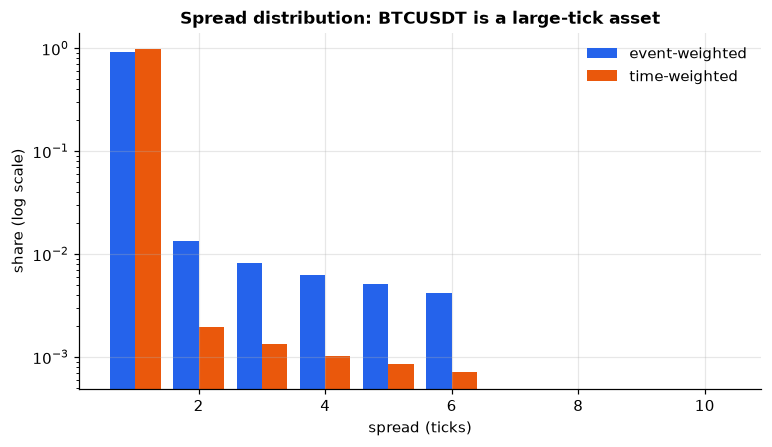

In [3]:
fig, ax = plt.subplots()
ticks = np.arange(1, 11)
ax.bar(ticks - 0.2, [table["event-weighted"].get(k, 0) for k in ticks], width=0.4, color=BLUE, label="event-weighted")
ax.bar(ticks + 0.2, [table["time-weighted"].get(k, 0) for k in ticks], width=0.4, color=ORANGE, label="time-weighted")
ax.set(yscale="log", xlabel="spread (ticks)", ylabel="share (log scale)", title="Spread distribution: BTCUSDT is a large-tick asset")
ax.legend()
save(fig, "01_spread_distribution")

The spread is at the minimum of **one tick about 99% of the time**. And one tick is 0.1 USDT on a
~70,000 USDT price, about **0.014 basis points**. That's absurdly tight: for comparison, Binance's
standard taker fee in 2024 was about 5 bp, several hundred times larger.

BTCUSDT is a textbook **large-tick asset**. Market makers would happily quote tighter if the exchange let
them. Since they can't, they line up in queues at the best bid and ask. Let's see how big those queues are
compared with the orders that hit them.

In [4]:
orders = aggregate_trades(load_trades())
one_tick = st == 1
print("Size waiting at the best bid (BTC), when spread = 1 tick:")
print(quotes.bid_qty[one_tick].describe(percentiles=[0.1, 0.5, 0.9]).round(3).to_string())
print(f"\nmedian aggressive order: {orders.qty.median():.3f} BTC")

Size waiting at the best bid (BTC), when spread = 1 tick:


count    1.465821e+07
mean     3.172000e+00
std      8.045000e+00
min      1.000000e-03
10%      2.000000e-02
50%      1.635000e+00
90%      7.899000e+00
max      5.292530e+02

median aggressive order: 0.023 BTC


The median queue at the touch (~1.6 BTC) is about 70 times the median order (~0.02 BTC). Most market orders take a
small bite out of the queue and the price doesn't move. The price only ticks when a queue is **depleted**
(by trades and cancellations) or when someone **improves** on it in the rare moments the spread is open.

## When the spread opens, how fast does it close?

A spread above 1 tick is an opportunity: anyone can post a better price inside it. How long does it
survive? This is the market's **resilience**.

203,503 wide-spread episodes
count    203503.0
mean          5.6
std          28.0
min           0.0
50%           1.0
90%          10.0
99%          92.0
max        2281.0


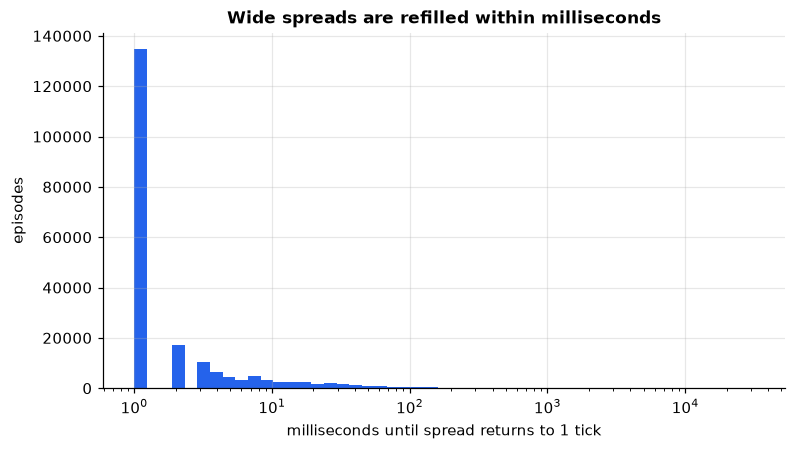

In [5]:
wide = st > 1
# Find runs of consecutive "wide" states: start where wide begins, end where it stops.
change = np.diff(wide.astype(int), prepend=0, append=0)
starts, ends = np.flatnonzero(change == 1), np.flatnonzero(change == -1)
episode_ms = (qts[np.minimum(ends, len(qts) - 1)] - qts[starts]).astype("int64")
print(f"{len(starts):,} wide-spread episodes")
print(pd.Series(episode_ms).describe(percentiles=[0.5, 0.9, 0.99]).round(1).to_string())

fig, ax = plt.subplots()
ax.hist(np.clip(episode_ms, 1, None), bins=np.logspace(0, 4.5, 50), color=BLUE)
ax.set(xscale="log", xlabel="milliseconds until spread returns to 1 tick", ylabel="episodes",
       title="Wide spreads are refilled within milliseconds")
save(fig, "01_spread_resilience")

Half of all wide-spread episodes are closed within **1 millisecond**, and 90% within 10 ms. No human is doing this. It's
market-making algorithms racing to post inside the gap, which is exactly the "competition on speed"
that large-tick markets create.

## The spread through the day

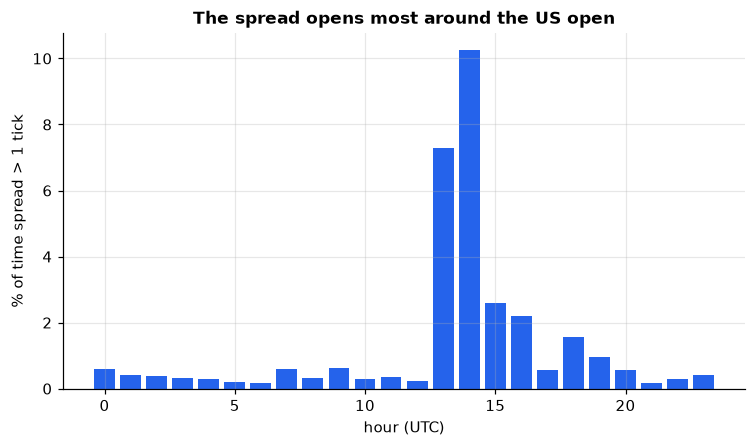

In [6]:
hour = quotes.ts.dt.hour.to_numpy()
by_hour = pd.DataFrame({"h": hour, "d": duration, "wide": duration * (st > 1), "ticks": duration * st}).groupby("h").sum()
fig, ax = plt.subplots()
ax.bar(by_hour.index, 100 * by_hour.wide / by_hour.d, color=BLUE)
ax.set(xlabel="hour (UTC)", ylabel="% of time spread > 1 tick", title="The spread opens most around the US open")
save(fig, "01_spread_by_hour")

The share of time the spread is wider than one tick jumps from under 1% to 7–10% at 13:00–15:00 UTC, the same hours as the
volume spike in chapter 0. More volatility means more risk of being run over (adverse selection,
chapter 4) for the makers, so they're quicker to pull their quotes, and gaps appear more often.

---
### Interview angle

<details><summary><b>"The spread on this stock is always one tick. What does that tell you?"</b></summary>

The tick size is binding: the competitive spread is below one tick. So queues are long, queue position is
valuable, and the information is in the queue *sizes* (imbalance) rather than in the spread. Being first in
the queue matters more than the price you quote, which is why HFT firms invest in speed.
</details>

<details><summary><b>"What happens if the exchange halves the tick size?"</b></summary>

The quoted spread likely tightens (good for small takers) and queues get shorter and spread across more
levels. Queue position becomes less valuable, so there's more "penny jumping" (improving by one tiny tick to
get ahead). Depth at the best quote falls, which can make large orders *more* expensive. The empirical
literature on tick-size changes (e.g. the 2016 US Tick Size Pilot, which *widened* ticks for small caps)
finds effects in both directions.
</details>

<details><summary><b>"Is the average spread 2.26 ticks or 1.24 ticks?"</b></summary>

Both: 2.26 weighting each book update equally, 1.24 weighting by clock time (wide spreads come with bursts of updates, so
event-weighting over-counts them). Time-weighted is what a trader arriving at a
random moment faces. Trade-weighted (spread at the moment of each trade) is what takers actually pay.
Always say which one you mean.
</details>

### Try this yourself
1. Compute the **trade-weighted** spread (the spread just before each order). Is it closer to the event- or time-weighted number? Why?
2. Does the spread widen *after* large orders? Condition on the previous order's size.